# Exploratory Data Analysis

This notebook performs exploratory data analysis for the Zenodo wind farm dataset using a **two-loop structure** designed to reduce repeated file reads and improve runtime efficiency.

## Objectives

- Inspect raw dataset structure across wind farms and turbines
- Review feature-description and event-information metadata
- Quantify dataset size and schema variation
- Measure overall and column-level missingness
- Analyze timestamp coverage and time-gap behavior across all turbines
- Perform representative visual EDA using a small sample of turbines
- Document findings that inform downstream cleaning, feature harmonization, and modeling

## Two-Loop Design

- **Loop 1:** iterate over all turbines once and collect lightweight structural summaries
- **Loop 2:** reload only representative turbines for visual EDA

This avoids repeatedly re-reading every turbine file for separate sections of the notebook.

## Setup Notebook

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from wtfd.config.config import (
    PROJECT_ROOT,
    load_config,
    get_path,
    ensure_directories,
    get_project_name,
    get_random_seed,
)
from wtfd.data_processing.discovery import (
    find_wind_farm_directories,
    find_turbine_csv_files,
    load_feature_description,
    load_event_info,
    load_scada_csv,
)
from wtfd.data_processing.preprocessing import (
    preprocess_scada_for_eda,
    optimize_dtypes,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

## Load Project Configuration

In [3]:
config = load_config()
ensure_directories(config)

PROJECT_NAME = get_project_name(config)
RANDOM_SEED = get_random_seed(config)

RAW_DATA_DIR = get_path("raw_zenodo", config)
EDA_OUTPUT_DIR = get_path("eda_artifacts", config)

print("Project root:", PROJECT_ROOT)
print("Project name:", PROJECT_NAME)
print("Random seed:", RANDOM_SEED)
print("Raw data dir:", RAW_DATA_DIR)
print("EDA output dir:", EDA_OUTPUT_DIR)

Project root: /mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection
Project name: wtfd
Random seed: 1984
Raw data dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data
EDA output dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/interim/eda


## Raw Dataset Structure

In [4]:
wind_farm_dirs = find_wind_farm_directories(
    RAW_DATA_DIR,
    require_datasets_subdir=True,
)

print("Wind farm directories found:")
for wf_dir in wind_farm_dirs:
    print(f" - {wf_dir.name}")

Wind farm directories found:
 - Wind Farm A
 - Wind Farm B
 - Wind Farm C


In [5]:
dataset_inventory_rows: list[dict] = []

for wf_dir in wind_farm_dirs:
    csv_files = find_turbine_csv_files(wf_dir)
    feature_desc_path = wf_dir / "feature_description.csv"
    event_info_path = wf_dir / "event_info.csv"

    dataset_inventory_rows.append(
        {
            "wind_farm": wf_dir.name,
            "n_turbine_csv_files": len(csv_files),
            "has_feature_description": feature_desc_path.exists(),
            "has_event_info": event_info_path.exists(),
            "feature_description_path": str(feature_desc_path),
            "event_info_path": str(event_info_path),
        }
    )

dataset_inventory_df = pd.DataFrame(dataset_inventory_rows).sort_values(by="wind_farm").reset_index(drop=True)
dataset_inventory_df

,wind_farm,n_turbine_csv_files,has_feature_description,has_event_info,feature_description_path,event_info_path
0,Wind Farm A,22,True,True,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/feature_description.csv,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/event_info.csv
1,Wind Farm B,15,True,True,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm B/feature_description.csv,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm B/event_info.csv
2,Wind Farm C,58,True,True,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm C/feature_description.csv,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm C/event_info.csv


## Inspect Feature Description Files

In [6]:
feature_description_tables: dict[str, pd.DataFrame] = {}

for wf_dir in wind_farm_dirs:
    wind_farm = wf_dir.name
    feature_df = load_feature_description(wf_dir)
    feature_description_tables[wind_farm] = feature_df

    print(f"\n=== {wind_farm}: feature_description.csv ===")
    print(f"Shape: {feature_df.shape}")
    display(feature_df.head(10))


=== Wind Farm A: feature_description.csv ===
Shape: (54, 6)


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
1,sensor_1,average,Wind absolute direction,�,True,False
2,sensor_2,average,Wind relative direction,�,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False
5,sensor_5,"maximum,minimum,std_dev,average",Pitch angle,�,True,False
6,sensor_6,average,Temperature in the hub controller,�C,False,False
7,sensor_7,average,Temperature in the top nacelle controller,�C,False,False
8,sensor_8,average,Temperature in the choke coils on the VCS-section,�C,False,False
9,sensor_9,average,Temperature on the VCP-board,�C,False,False



=== Wind Farm B: feature_description.csv ===
Shape: (63, 6)


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,"maximum,minimum,average,std_dev",Total negative reactive power,kvarh,False,True
1,sensor_1,"maximum,std_dev,average,minimum",Total negative active power,kWh,False,True
2,sensor_2,"average,minimum,maximum,std_dev",Total positive reactive power,kvarh,False,True
3,sensor_3,"maximum,std_dev,minimum,average",Total positive active power,kWh,False,True
4,sensor_4,"average,maximum,minimum,std_dev",Absolute wind direction,�,True,False
5,sensor_5,"average,maximum,std_dev,minimum",Torque delta calculated,kNm,False,False
6,sensor_6,"average,minimum,std_dev,maximum",Wind speed anemometer 2 calculated,m/s,False,False
7,sensor_7,"std_dev,maximum,minimum,average",Cable load,%,False,False
8,sensor_8,"maximum,average,minimum,std_dev",Outside temperature,�C,False,False
9,sensor_9,"average,minimum,maximum,std_dev",Estimated tower natural frequency,mHz,False,False



=== Wind Farm C: feature_description.csv ===
Shape: (238, 6)


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,"maximum,minimum,std_dev,average","ABB-LS Input K1, IL1",A,False,False
1,sensor_1,"maximum,minimum,std_dev,average",Generator acceleration,rpm/s,False,False
2,power_2,"average,maximum,std_dev,minimum",ABB-LS Active Power,kW,False,False
3,sensor_3,"average,maximum,minimum,std_dev",Active power aeration motor A,%,False,False
4,sensor_4,"average,maximum,minimum,std_dev",Active power aeration motor B,%,False,False
5,power_5,"average,maximum,minimum,std_dev",Active power grid side converter,kW,False,False
6,power_6,"average,maximum,minimum,std_dev",Active power HV grid,kW,False,False
7,sensor_7,"average,maximum,minimum,std_dev",Ambient temperature,Celsius,False,False
8,sensor_8,"average,maximum,minimum,std_dev",Generator angle speed,rad/s,False,False
9,sensor_9,"average,maximum,minimum,std_dev",Battery charge 1,A,False,False


In [7]:
feature_description_summary_rows: list[dict] = []

for wind_farm, feature_df in feature_description_tables.items():
    present_cols = {str(col) for col in feature_df.columns}
    feature_description_summary_rows.append(
        {
            "wind_farm": wind_farm,
            "n_rows": len(feature_df),
            "columns": ", ".join(feature_df.columns.astype(str)),
            "has_sensor_name": "sensor_name" in present_cols,
            "has_description": "description" in present_cols,
            "has_unit": "unit" in present_cols,
        }
    )

feature_description_summary_df = pd.DataFrame(feature_description_summary_rows).sort_values(by="wind_farm").reset_index(drop=True)
feature_description_summary_df

,wind_farm,n_rows,columns,has_sensor_name,has_description,has_unit
0,Wind Farm A,54,"sensor_name, statistics_type, description, unit, is_angle, is_counter",True,True,True
1,Wind Farm B,63,"sensor_name, statistics_type, description, unit, is_angle, is_counter",True,True,True
2,Wind Farm C,238,"sensor_name, statistics_type, description, unit, is_angle, is_counter",True,True,True


## Inspect Event Information Files

In [8]:
event_info_tables: dict[str, pd.DataFrame] = {}

for wf_dir in wind_farm_dirs:
    wind_farm = wf_dir.name
    event_df = load_event_info(wf_dir)
    event_info_tables[wind_farm] = event_df

    print(f"\n=== {wind_farm}: event_info.csv ===")
    print(f"Shape: {event_df.shape}")
    display(event_df.head(10))


=== Wind Farm A: event_info.csv ===
Shape: (22, 8)


,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,11,68,anomaly,2023-07-28 13:20:00,52063,2023-08-11 13:10:00,54076,Transformer failure
1,21,22,anomaly,2023-08-12 09:50:00,51888,2023-08-19 10:00:00,52892,Hydraulic group
2,21,72,anomaly,2023-10-10 08:40:00,52497,2023-10-17 08:40:00,53505,Gearbox failure
3,0,73,anomaly,2023-06-10 11:40:00,52745,2023-06-17 11:40:00,53753,Hydraulic group
4,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure
5,0,26,anomaly,2023-10-12 10:20:00,52261,2023-10-19 10:20:00,53269,Hydraulic group
6,10,40,anomaly,2022-12-26 00:00:00,51363,2023-01-26 13:00:00,55870,Generator bearing failure
7,10,42,anomaly,2023-09-09 15:50:00,52303,2023-09-16 15:50:00,53309,Hydraulic group
8,10,10,anomaly,2023-10-11 08:40:00,52611,2023-10-18 08:40:00,53591,Gearbox failure
9,13,45,anomaly,2023-04-19 18:10:00,52731,2023-04-26 18:10:00,53738,Hydraulic group



=== Wind Farm B: event_info.csv ===
Shape: (15, 8)


,asset_id,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,14,34,anomaly,2023-08-24 00:00:00,52531,2023-09-15 00:00:00,55699,high temperature in transformer cell
1,13,7,anomaly,2023-07-01 00:00:00,52703,2023-08-01 00:00:00,57167,high temperature in transformer cell
2,6,53,anomaly,2023-12-26 16:40:00,52559,2024-02-06 16:30:00,58606,Rotor Bearing 2 - Damage
3,7,27,anomaly,2023-09-01 00:00:00,52619,2023-11-01 00:00:00,61403,Turbine is stopped due to a main bearing damage
4,11,19,anomaly,2023-02-03 00:00:00,52673,2023-02-23 00:00:00,55553,high temperature in transformer cell
5,12,77,anomaly,2023-06-01 00:00:00,52991,2023-07-31 00:00:00,61631,Turbine is in standstill since 01.08 due to rotorbearing damage.
6,2,83,normal,2023-07-01 00:00:00,52329,2023-09-30 00:00:00,65433,NaN
7,14,52,normal,2023-07-14 00:00:00,52675,2023-07-28 00:00:00,54691,NaN
8,0,21,normal,2023-09-22 20:10:00,52217,2023-10-01 20:10:00,53513,NaN
9,13,2,normal,2023-08-09 19:20:00,52703,2023-08-23 04:20:00,54629,NaN



=== Wind Farm C: event_info.csv ===
Shape: (58, 8)


,asset_id,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,50,55,anomaly,2023-10-29 11:30:00,52848,2023-11-15 15:30:00,55320,Harting plug Nacelle/HUB damaged + NCR20_HUB: Wiring blade control system
1,38,81,anomaly,2023-11-16 01:30:00,52704,2023-11-18 14:00:00,53067,"Converter Failure from 17.11 12:30 - 18.11. 13:57, Fuse Filter Supply"
2,21,47,anomaly,2023-12-22 15:00:00,52416,2023-12-27 13:40:00,53128,"Failure due to Rotorbrake and Hydraulic problemes - Hydraulic pump A disabeld, 2h later turbine back in production - Analysis indicates a longer anomaly in temp_hydraulic_oil_tank_1_average until ..."
3,2,12,anomaly,2023-06-27 00:00:00,52560,2023-07-19 15:00:00,55818,"10115 : Oil level error, two-pump mode + Oil Leakage Gear Oil Supply + 12019: Rotor brake B cannot be closed + P20_yaw carbon brush damaged"
4,34,4,anomaly,2023-07-31 10:00:00,52992,2023-08-19 10:00:00,55728,23020 : Axis 3 not ready-to-operate
5,34,18,anomaly,2023-09-13 00:00:00,51408,2023-09-16 23:50:00,51983,We had some failures (störung 24VAC Versorgung Rotorbremse) on the 16th in the afternoon. From 17th onwards a longer standstill where we don't know the root cause to.
6,52,28,anomaly,2023-05-28 13:00:00,52704,2023-06-17 20:30:00,55629,P20_spinner_carbonbrush defekt + P20_Accumulators_hydraulic system
7,52,39,anomaly,2023-10-19 13:00:00,52848,2023-10-24 15:20:00,53582,15004 : Safety chain relay open + 93005 : Gear oil cooler bypass valve
8,12,66,anomaly,2023-01-17 00:00:00,51696,2023-01-23 13:00:00,52638,"Pitchfailure - defect Beckhoffcard, Axis 2, rectified on 23/01 - Anomalie liegt aber länger an als der Fehler, Batterien waren ok"
9,12,15,anomaly,2023-02-06 00:00:00,51984,2023-02-23 00:00:00,54432,Randomn small failures regarding pitch resulting in a longer standstill due to a defect pitch encoder (26/02)


In [9]:
event_info_summary_rows: list[dict] = []

for wind_farm, event_df in event_info_tables.items():
    event_info_summary_rows.append(
        {
            "wind_farm": wind_farm,
            "n_rows": len(event_df),
            "columns": ", ".join(event_df.columns.astype(str)),
        }
    )

event_info_summary_df = pd.DataFrame(event_info_summary_rows).sort_values(by="wind_farm").reset_index(drop=True)
event_info_summary_df

,wind_farm,n_rows,columns
0,Wind Farm A,22,"asset, event_id, event_label, event_start, event_start_id, event_end, event_end_id, event_description"
1,Wind Farm B,15,"asset_id, event_id, event_label, event_start, event_start_id, event_end, event_end_id, event_description"
2,Wind Farm C,58,"asset_id, event_id, event_label, event_start, event_start_id, event_end, event_end_id, event_description"


## Enumerate Turbine Files

In [10]:
turbine_file_rows: list[dict] = []

for wf_dir in wind_farm_dirs:
    wind_farm = wf_dir.name
    csv_files = find_turbine_csv_files(wf_dir)

    for csv_path in csv_files:
        turbine_file_rows.append(
            {
                "wind_farm": wind_farm,
                "turbine_id": csv_path.stem,
                "csv_path": str(csv_path),
            }
        )

turbine_files_df = pd.DataFrame(turbine_file_rows).sort_values(by=["wind_farm", "turbine_id"]).reset_index(drop=True)
turbine_files_df.head(20)

,wind_farm,turbine_id,csv_path
0,Wind Farm A,0,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/0.csv
1,Wind Farm A,10,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/10.csv
2,Wind Farm A,13,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/13.csv
3,Wind Farm A,14,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/14.csv
4,Wind Farm A,17,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/17.csv
5,Wind Farm A,22,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/22.csv
6,Wind Farm A,24,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/24.csv
7,Wind Farm A,25,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/25.csv
8,Wind Farm A,26,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/26.csv
9,Wind Farm A,3,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/3.csv


In [11]:
print(f"Total turbines discovered: {len(turbine_files_df)}")
(
    turbine_files_df.groupby("wind_farm")["turbine_id"]
    .count()
    .rename("n_turbines")
    .reset_index()
)

Total turbines discovered: 95


,wind_farm,n_turbines
0,Wind Farm A,22
1,Wind Farm B,15
2,Wind Farm C,58


## Helper Functions for Structural EDA

These helper functions are local to the notebook and support the first loop.

In [12]:
def summarize_dataframe_structure(
    df: pd.DataFrame,
    wind_farm: str,
    turbine_id: str,
    source_file: str,
) -> dict:
    """
    Build a compact structural summary for a turbine dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Lightly preprocessed turbine dataframe.
    wind_farm : str
        Wind farm identifier.
    turbine_id : str
        Turbine identifier.
    source_file : str
        Source CSV path.

    Returns
    -------
    dict
        Structural metadata used to build downstream summary tables.
    """
    has_timestamp = "timestamp" in df.columns

    if has_timestamp:
        ts = df["timestamp"]
        timestamp_min = ts.min()
        timestamp_max = ts.max()
        n_missing_timestamps = int(ts.isna().sum())
    else:
        timestamp_min = pd.NaT
        timestamp_max = pd.NaT
        n_missing_timestamps = np.nan

    return {
        "wind_farm": wind_farm,
        "turbine_id": turbine_id,
        "source_file": source_file,
        "n_rows": int(df.shape[0]),
        "n_columns": int(df.shape[1]),
        "has_timestamp": has_timestamp,
        "timestamp_min": None if pd.isna(timestamp_min) else str(timestamp_min),
        "timestamp_max": None if pd.isna(timestamp_max) else str(timestamp_max),
        "n_missing_timestamps": n_missing_timestamps,
        "column_names": "|".join(map(str, df.columns)),
    }


def compute_time_gap_metrics(
    df: pd.DataFrame,
    timestamp_col: str = "timestamp",
) -> tuple[dict, pd.Series]:
    """
    Compute time-gap summary metrics for a turbine dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a timestamp column.
    timestamp_col : str, optional
        Name of the timestamp column.

    Returns
    -------
    tuple[dict, pd.Series]
        A tuple containing:
        1. a dictionary of summary gap metrics
        2. a Series of individual gap values in minutes
    """
    if timestamp_col not in df.columns:
        return (
            {
                "n_intervals": 0,
                "min_gap_minutes": np.nan,
                "median_gap_minutes": np.nan,
                "mean_gap_minutes": np.nan,
                "max_gap_minutes": np.nan,
                "p95_gap_minutes": np.nan,
                "n_gaps_gt_10min": 0,
                "n_gaps_gt_60min": 0,
                "n_gaps_gt_1440min": 0,
            },
            pd.Series(dtype="float64"),
        )

    ts = df[timestamp_col].dropna().sort_values()

    if len(ts) < 2:
        return (
            {
                "n_intervals": 0,
                "min_gap_minutes": np.nan,
                "median_gap_minutes": np.nan,
                "mean_gap_minutes": np.nan,
                "max_gap_minutes": np.nan,
                "p95_gap_minutes": np.nan,
                "n_gaps_gt_10min": 0,
                "n_gaps_gt_60min": 0,
                "n_gaps_gt_1440min": 0,
            },
            pd.Series(dtype="float64"),
        )

    gaps = ts.diff().dropna().dt.total_seconds() / 60.0

    summary = {
        "n_intervals": int(len(gaps)),
        "min_gap_minutes": float(gaps.min()),
        "median_gap_minutes": float(gaps.median()),
        "mean_gap_minutes": float(gaps.mean()),
        "max_gap_minutes": float(gaps.max()),
        "p95_gap_minutes": float(gaps.quantile(0.95)),
        "n_gaps_gt_10min": int((gaps > 10).sum()),
        "n_gaps_gt_60min": int((gaps > 60).sum()),
        "n_gaps_gt_1440min": int((gaps > 1440).sum()),
    }

    return summary, gaps


def find_candidate_column(df: pd.DataFrame, patterns: list[str]) -> str | None:
    """
    Find the first column whose name contains one of the supplied patterns.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    patterns : list[str]
        Candidate substrings to search for in column names.

    Returns
    -------
    str | None
        The first matching column name, or None if no match is found.
    """
    lower_map = {str(col).lower(): str(col) for col in df.columns}

    for pattern in patterns:
        for lower_name, original_name in lower_map.items():
            if pattern in lower_name:
                return original_name

    return None

## Loop 1 — All-Turbine Structural EDA

Each CSV is read once and used to compute all lightweight structural summaries:

- dataframe structure
- schema presence
- overall missingness
- column-level missingness
- timestamp coverage
- time-gap metrics
- gap bucket counts
- representative turbine selection metadata

In [13]:
metadata_rows: list[dict] = []
dataframe_summary_rows: list[dict] = []
missingness_rows: list[dict] = []
column_missingness_rows: list[dict] = []
time_gap_rows: list[dict] = []
gap_bucket_rows: list[dict] = []
gap_distribution_rows: list[dict] = []
schema_presence_rows: list[dict] = []

representative_candidates: dict[str, dict] = {}

gap_bins = [0, 1, 10, 60, 360, 1440, np.inf]
gap_labels = ["0-1 min", "1-10 min", "10-60 min", "1-6 hr", "6-24 hr", ">24 hr"]

for row in tqdm(turbine_files_df.itertuples(index=False), total=len(turbine_files_df)):
    wind_farm = row.wind_farm
    turbine_id = row.turbine_id
    csv_path = Path(row.csv_path)

    raw_df = load_scada_csv(csv_path)
    df = preprocess_scada_for_eda(raw_df)
    df = optimize_dtypes(df, skip_columns={"timestamp"})

    structure_summary = summarize_dataframe_structure(
        df=df,
        wind_farm=wind_farm,
        turbine_id=turbine_id,
        source_file=str(csv_path),
    )
    metadata_rows.append(structure_summary)
    dataframe_summary_rows.append(
        {
            key: structure_summary[key]
            for key in [
                "wind_farm",
                "turbine_id",
                "n_rows",
                "n_columns",
                "has_timestamp",
                "timestamp_min",
                "timestamp_max",
                "n_missing_timestamps",
            ]
        }
    )

    for col in df.columns:
        schema_presence_rows.append(
            {
                "wind_farm": wind_farm,
                "turbine_id": turbine_id,
                "column": str(col),
            }
        )

    total_cells = int(df.shape[0] * df.shape[1])
    total_missing = int(df.isna().sum().sum())

    missingness_rows.append(
        {
            "wind_farm": wind_farm,
            "turbine_id": turbine_id,
            "total_cells": total_cells,
            "total_missing": total_missing,
            "missing_fraction": total_missing / total_cells if total_cells > 0 else np.nan,
            "n_missing_timestamps": structure_summary["n_missing_timestamps"],
        }
    )

    col_missing = df.isna().mean()
    for col, frac in col_missing.items():
        column_missingness_rows.append(
            {
                "wind_farm": wind_farm,
                "turbine_id": turbine_id,
                "column": str(col),
                "missing_fraction": float(frac),
            }
        )

    gap_summary, gaps = compute_time_gap_metrics(df)
    time_gap_rows.append({"wind_farm": wind_farm, "turbine_id": turbine_id, **gap_summary})

    if len(gaps) > 0:
        gap_buckets = pd.cut(gaps, bins=gap_bins, labels=gap_labels, right=True)
        bucket_counts = gap_buckets.value_counts().reindex(gap_labels, fill_value=0)

        for bucket, count in bucket_counts.items():
            gap_bucket_rows.append(
                {
                    "wind_farm": wind_farm,
                    "turbine_id": turbine_id,
                    "gap_bucket": str(bucket),
                    "count": int(count),
                }
            )

        gap_distribution_rows.extend(
            {
                "wind_farm": wind_farm,
                "turbine_id": turbine_id,
                "gap_minutes": float(gap),
            }
            for gap in gaps.values
        )
    else:
        for bucket in gap_labels:
            gap_bucket_rows.append(
                {
                    "wind_farm": wind_farm,
                    "turbine_id": turbine_id,
                    "gap_bucket": bucket,
                    "count": 0,
                }
            )

    if wind_farm not in representative_candidates:
        representative_candidates[wind_farm] = {
            "wind_farm": wind_farm,
            "turbine_id": turbine_id,
            "csv_path": str(csv_path),
        }

    del raw_df
    del df
    gc.collect()

  0%|          | 0/95 [00:00<?, ?it/s]

## Build Derived Summary Tables

In [14]:
turbine_metadata_df = pd.DataFrame(metadata_rows).sort_values(by=["wind_farm", "turbine_id"]).reset_index(drop=True)
dataframe_summary_df = pd.DataFrame(dataframe_summary_rows).sort_values(by=["wind_farm", "turbine_id"]).reset_index(drop=True)
missingness_df = pd.DataFrame(missingness_rows).sort_values(by=["wind_farm", "turbine_id"]).reset_index(drop=True)
column_missingness_df = pd.DataFrame(column_missingness_rows).sort_values(by=["wind_farm", "turbine_id", "column"]).reset_index(drop=True)
time_gap_df = pd.DataFrame(time_gap_rows).sort_values(by=["wind_farm", "turbine_id"]).reset_index(drop=True)
gap_distribution_df = pd.DataFrame(gap_distribution_rows)
gap_bucket_summary_df = pd.DataFrame(gap_bucket_rows).sort_values(by=["wind_farm", "turbine_id", "gap_bucket"]).reset_index(drop=True)
schema_presence_df = pd.DataFrame(schema_presence_rows).drop_duplicates().sort_values(by=["wind_farm", "turbine_id", "column"]).reset_index(drop=True)
representative_turbines_df = pd.DataFrame(representative_candidates.values()).sort_values(by=["wind_farm", "turbine_id"]).reset_index(drop=True)

turbine_metadata_df.head(10)

,wind_farm,turbine_id,source_file,n_rows,n_columns,has_timestamp,timestamp_min,timestamp_max,n_missing_timestamps,column_names
0,Wind Farm A,0,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/0.csv,54986,87,True,2022-08-04 06:10:00,2023-08-24 06:10:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
1,Wind Farm A,10,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/10.csv,53592,87,True,2022-10-09 08:40:00,2023-10-18 08:40:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
2,Wind Farm A,13,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/13.csv,54010,87,True,2022-04-30 13:20:00,2023-05-25 10:20:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
3,Wind Farm A,14,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/14.csv,54197,87,True,2022-03-03 14:00:00,2023-03-16 18:40:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
4,Wind Farm A,17,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/17.csv,55090,87,True,2022-10-31 15:20:00,2023-11-20 00:40:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
5,Wind Farm A,22,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/22.csv,53036,87,True,2022-08-12 09:50:00,2023-08-20 09:50:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
6,Wind Farm A,24,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/24.csv,55003,87,True,2022-04-24 15:00:00,2023-05-13 11:20:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
7,Wind Farm A,25,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/25.csv,54712,87,True,2022-05-23 06:50:00,2023-06-09 02:30:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
8,Wind Farm A,26,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/26.csv,53702,87,True,2022-10-12 10:20:00,2023-10-22 10:20:00,0,time_stamp|asset_id|id|train_test|status_type_id|sensor_0_avg|sensor_1_avg|sensor_2_avg|wind_speed_3_avg|wind_speed_4_avg|wind_speed_3_max|wind_speed_3_min|wind_speed_3_std|sensor_5_avg|sensor_5_m...
9,Wind Farm A,3,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm 

## Dataset Size Summary

In [15]:
dataset_size_summary_df = (
    turbine_metadata_df.groupby("wind_farm")
    .agg(
        n_turbines=("turbine_id", "count"),
        total_rows=("n_rows", "sum"),
        mean_rows_per_turbine=("n_rows", "mean"),
        min_rows=("n_rows", "min"),
        max_rows=("n_rows", "max"),
        mean_columns=("n_columns", "mean"),
    )
    .reset_index()
)
dataset_size_summary_df

,wind_farm,n_turbines,total_rows,mean_rows_per_turbine,min_rows,max_rows,mean_columns
0,Wind Farm A,22,1196747,54397.590909,53036,56158,87.0
1,Wind Farm B,15,859065,57271.000000,53514,66154,258.0
2,Wind Farm C,58,3187136,54950.620690,52086,63003,958.0


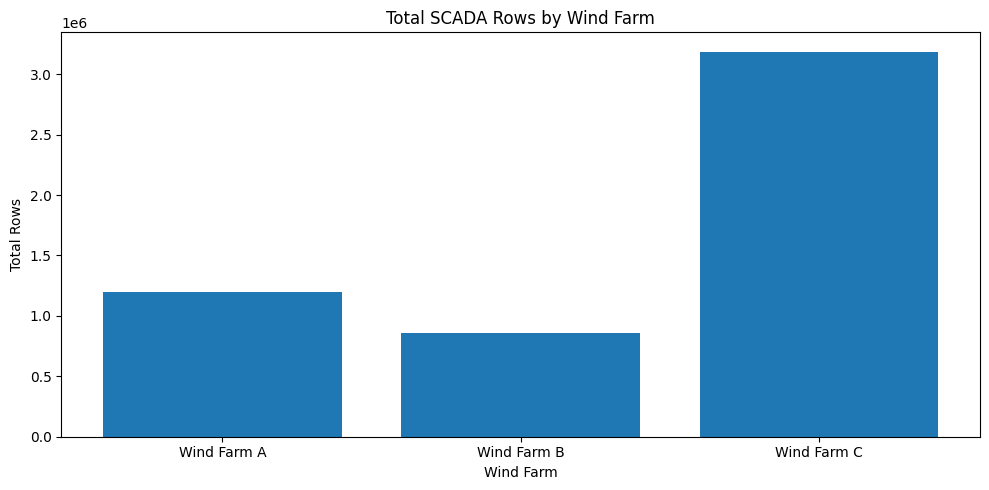

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(dataset_size_summary_df["wind_farm"], dataset_size_summary_df["total_rows"])
plt.title("Total SCADA Rows by Wind Farm")
plt.xlabel("Wind Farm")
plt.ylabel("Total Rows")
plt.tight_layout()
plt.show()

## Schema Inspection Across All Turbines

In [17]:
schema_matrix_df = (
    schema_presence_df.assign(
        turbine_key=lambda x: x["wind_farm"] + "__" + x["turbine_id"],
        present=1,
    )
    .pivot_table(
        index="column",
        columns="turbine_key",
        values="present",
        aggfunc="max",
        fill_value=0,
    )
    .reset_index()
)
schema_matrix_df.head(20)

turbine_key,column,Wind Farm A__0,Wind Farm A__10,Wind Farm A__13,Wind Farm A__14,Wind Farm A__17,Wind Farm A__22,Wind Farm A__24,Wind Farm A__25,Wind Farm A__26,Wind Farm A__3,Wind Farm A__38,Wind Farm A__40,Wind Farm A__42,Wind Farm A__45,Wind Farm A__51,Wind Farm A__68,Wind Farm A__69,Wind Farm A__71,Wind Farm A__72,Wind Farm A__73,Wind Farm A__84,Wind Farm A__92,Wind Farm B__19,Wind Farm B__2,Wind Farm B__21,Wind Farm B__23,Wind Farm B__27,Wind Farm B__34,Wind Farm B__52,Wind Farm B__53,Wind Farm B__7,Wind Farm B__74,Wind Farm B__77,Wind Farm B__82,Wind Farm B__83,Wind Farm B__86,Wind Farm B__87,Wind Farm C__1,Wind Farm C__11,Wind Farm C__12,Wind Farm C__15,Wind Farm C__16,Wind Farm C__18,Wind Farm C__20,Wind Farm C__28,Wind Farm C__29,Wind Farm C__30,Wind Farm C__31,Wind Farm C__32,Wind Farm C__33,Wind Farm C__35,Wind Farm C__36,Wind Farm C__37,Wind Farm C__39,Wind Farm C__4,Wind Farm C__41,Wind Farm C__43,Wind Farm C__44,Wind Farm C__46,Wind Farm C__47,Wind Farm C__48,Wind Farm C__49,Wind Farm C__5,Wind Farm C__50,Wind Farm C__54,Wind Farm C__55,Wind Farm C__56,Wind Farm C__57,Wind Farm C__58,Wind Farm C__59,Wind Farm C__6,Wind Farm C__60,Wind Farm C__61,Wind Farm C__62,Wind Farm C__63,Wind Farm C__64,Wind Farm C__65,Wind Farm C__66,Wind Farm C__67,Wind Farm C__70,Wind Farm C__75,Wind Farm C__76,Wind Farm C__78,Wind Farm C__79,Wind Farm C__8,Wind Farm C__80,Wind Farm C__81,Wind Farm C__85,Wind Farm C__88,Wind Farm C__89,Wind Farm C__9,Wind Farm C__90,Wind Farm C__91,Wind Farm C__93,Wind Farm C__94
0,asset_id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,power_17_avg,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,power_17_max,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,power_17_min,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,power_17_std,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,power_29_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,power_29_max,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,power_29_min,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,power_29_std,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [18]:
column_presence_summary_df = (
    schema_matrix_df.assign(
        turbines_present=lambda x: x.drop(columns="column").sum(axis=1),
        presence_fraction=lambda x: x["turbines_present"] / (schema_matrix_df.shape[1] - 1),
    )
    .sort_values(by=["turbines_present", "column"], ascending=[False, True])
    .reset_index(drop=True)
)
column_presence_summary_df.head(20)

turbine_key,column,Wind Farm A__0,Wind Farm A__10,Wind Farm A__13,Wind Farm A__14,Wind Farm A__17,Wind Farm A__22,Wind Farm A__24,Wind Farm A__25,Wind Farm A__26,Wind Farm A__3,Wind Farm A__38,Wind Farm A__40,Wind Farm A__42,Wind Farm A__45,Wind Farm A__51,Wind Farm A__68,Wind Farm A__69,Wind Farm A__71,Wind Farm A__72,Wind Farm A__73,Wind Farm A__84,Wind Farm A__92,Wind Farm B__19,Wind Farm B__2,Wind Farm B__21,Wind Farm B__23,Wind Farm B__27,Wind Farm B__34,Wind Farm B__52,Wind Farm B__53,Wind Farm B__7,Wind Farm B__74,Wind Farm B__77,Wind Farm B__82,Wind Farm B__83,Wind Farm B__86,Wind Farm B__87,Wind Farm C__1,Wind Farm C__11,Wind Farm C__12,Wind Farm C__15,Wind Farm C__16,Wind Farm C__18,Wind Farm C__20,Wind Farm C__28,Wind Farm C__29,Wind Farm C__30,Wind Farm C__31,Wind Farm C__32,Wind Farm C__33,Wind Farm C__35,Wind Farm C__36,Wind Farm C__37,Wind Farm C__39,Wind Farm C__4,Wind Farm C__41,Wind Farm C__43,Wind Farm C__44,Wind Farm C__46,Wind Farm C__47,Wind Farm C__48,Wind Farm C__49,Wind Farm C__5,Wind Farm C__50,Wind Farm C__54,Wind Farm C__55,Wind Farm C__56,Wind Farm C__57,Wind Farm C__58,Wind Farm C__59,Wind Farm C__6,Wind Farm C__60,Wind Farm C__61,Wind Farm C__62,Wind Farm C__63,Wind Farm C__64,Wind Farm C__65,Wind Farm C__66,Wind Farm C__67,Wind Farm C__70,Wind Farm C__75,Wind Farm C__76,Wind Farm C__78,Wind Farm C__79,Wind Farm C__8,Wind Farm C__80,Wind Farm C__81,Wind Farm C__85,Wind Farm C__88,Wind Farm C__89,Wind Farm C__9,Wind Farm C__90,Wind Farm C__91,Wind Farm C__93,Wind Farm C__94,turbines_present,presence_fraction
0,asset_id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
1,id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
2,sensor_0_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
3,sensor_10_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
4,sensor_12_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
5,sensor_13_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
6,sensor_14_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
7,sensor_15_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
8,sensor_16_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
9,sensor_18_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0


In [19]:
schema_variability_summary = {
    "n_turbines": int(len(turbine_files_df)),
    "n_union_columns": int(schema_matrix_df.shape[0]),
    "n_intersection_columns": int((column_presence_summary_df["presence_fraction"] == 1.0).sum()),
    "intersection_fraction_of_union": float(
        (column_presence_summary_df["presence_fraction"] == 1.0).sum() / schema_matrix_df.shape[0]
    ) if schema_matrix_df.shape[0] > 0 else np.nan,
}
schema_variability_summary

{'n_turbines': 95,
 'n_union_columns': 1027,
 'n_intersection_columns': 50,
 'intersection_fraction_of_union': 0.04868549172346641}

### Interpretation

A low intersection of column names across turbines supports the conclusion that a naive shared raw schema should not be imposed.

In [20]:
common_columns_df = column_presence_summary_df.loc[column_presence_summary_df["presence_fraction"] == 1.0].copy()
rare_columns_df = column_presence_summary_df.loc[column_presence_summary_df["presence_fraction"] < 0.5].copy()

print("Columns present in all turbines:")
display(common_columns_df.head(20))

print("Columns present in fewer than half of turbines:")
display(rare_columns_df.head(20))

Columns present in all turbines:


turbine_key,column,Wind Farm A__0,Wind Farm A__10,Wind Farm A__13,Wind Farm A__14,Wind Farm A__17,Wind Farm A__22,Wind Farm A__24,Wind Farm A__25,Wind Farm A__26,Wind Farm A__3,Wind Farm A__38,Wind Farm A__40,Wind Farm A__42,Wind Farm A__45,Wind Farm A__51,Wind Farm A__68,Wind Farm A__69,Wind Farm A__71,Wind Farm A__72,Wind Farm A__73,Wind Farm A__84,Wind Farm A__92,Wind Farm B__19,Wind Farm B__2,Wind Farm B__21,Wind Farm B__23,Wind Farm B__27,Wind Farm B__34,Wind Farm B__52,Wind Farm B__53,Wind Farm B__7,Wind Farm B__74,Wind Farm B__77,Wind Farm B__82,Wind Farm B__83,Wind Farm B__86,Wind Farm B__87,Wind Farm C__1,Wind Farm C__11,Wind Farm C__12,Wind Farm C__15,Wind Farm C__16,Wind Farm C__18,Wind Farm C__20,Wind Farm C__28,Wind Farm C__29,Wind Farm C__30,Wind Farm C__31,Wind Farm C__32,Wind Farm C__33,Wind Farm C__35,Wind Farm C__36,Wind Farm C__37,Wind Farm C__39,Wind Farm C__4,Wind Farm C__41,Wind Farm C__43,Wind Farm C__44,Wind Farm C__46,Wind Farm C__47,Wind Farm C__48,Wind Farm C__49,Wind Farm C__5,Wind Farm C__50,Wind Farm C__54,Wind Farm C__55,Wind Farm C__56,Wind Farm C__57,Wind Farm C__58,Wind Farm C__59,Wind Farm C__6,Wind Farm C__60,Wind Farm C__61,Wind Farm C__62,Wind Farm C__63,Wind Farm C__64,Wind Farm C__65,Wind Farm C__66,Wind Farm C__67,Wind Farm C__70,Wind Farm C__75,Wind Farm C__76,Wind Farm C__78,Wind Farm C__79,Wind Farm C__8,Wind Farm C__80,Wind Farm C__81,Wind Farm C__85,Wind Farm C__88,Wind Farm C__89,Wind Farm C__9,Wind Farm C__90,Wind Farm C__91,Wind Farm C__93,Wind Farm C__94,turbines_present,presence_fraction
0,asset_id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
1,id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
2,sensor_0_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
3,sensor_10_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
4,sensor_12_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
5,sensor_13_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
6,sensor_14_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
7,sensor_15_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
8,sensor_16_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0
9,sensor_18_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,95,1.0


Columns present in fewer than half of turbines:


turbine_key,column,Wind Farm A__0,Wind Farm A__10,Wind Farm A__13,Wind Farm A__14,Wind Farm A__17,Wind Farm A__22,Wind Farm A__24,Wind Farm A__25,Wind Farm A__26,Wind Farm A__3,Wind Farm A__38,Wind Farm A__40,Wind Farm A__42,Wind Farm A__45,Wind Farm A__51,Wind Farm A__68,Wind Farm A__69,Wind Farm A__71,Wind Farm A__72,Wind Farm A__73,Wind Farm A__84,Wind Farm A__92,Wind Farm B__19,Wind Farm B__2,Wind Farm B__21,Wind Farm B__23,Wind Farm B__27,Wind Farm B__34,Wind Farm B__52,Wind Farm B__53,Wind Farm B__7,Wind Farm B__74,Wind Farm B__77,Wind Farm B__82,Wind Farm B__83,Wind Farm B__86,Wind Farm B__87,Wind Farm C__1,Wind Farm C__11,Wind Farm C__12,Wind Farm C__15,Wind Farm C__16,Wind Farm C__18,Wind Farm C__20,Wind Farm C__28,Wind Farm C__29,Wind Farm C__30,Wind Farm C__31,Wind Farm C__32,Wind Farm C__33,Wind Farm C__35,Wind Farm C__36,Wind Farm C__37,Wind Farm C__39,Wind Farm C__4,Wind Farm C__41,Wind Farm C__43,Wind Farm C__44,Wind Farm C__46,Wind Farm C__47,Wind Farm C__48,Wind Farm C__49,Wind Farm C__5,Wind Farm C__50,Wind Farm C__54,Wind Farm C__55,Wind Farm C__56,Wind Farm C__57,Wind Farm C__58,Wind Farm C__59,Wind Farm C__6,Wind Farm C__60,Wind Farm C__61,Wind Farm C__62,Wind Farm C__63,Wind Farm C__64,Wind Farm C__65,Wind Farm C__66,Wind Farm C__67,Wind Farm C__70,Wind Farm C__75,Wind Farm C__76,Wind Farm C__78,Wind Farm C__79,Wind Farm C__8,Wind Farm C__80,Wind Farm C__81,Wind Farm C__85,Wind Farm C__88,Wind Farm C__89,Wind Farm C__9,Wind Farm C__90,Wind Farm C__91,Wind Farm C__93,Wind Farm C__94,turbines_present,presence_fraction
958,sensor_17_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37,0.389474
959,sensor_2_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37,0.389474
960,sensor_5_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37,0.389474
961,sensor_5_max,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37,0.389474
962,sensor_5_min,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37,0.389474
963,sensor_5_std,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37,0.389474
964,sensor_6_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37,0.389474
965,power_29_avg,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,0.231579
966,power_29_max,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,0.231579
967,power_29_min,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,0.231579


## 11. Missingness Overview Across All Turbines

In [21]:
missingness_df.head(10)

,wind_farm,turbine_id,total_cells,total_missing,missing_fraction,n_missing_timestamps
0,Wind Farm A,0,4783782,2,4.180793e-07,0
1,Wind Farm A,10,4662504,6,1.286862e-06,0
2,Wind Farm A,13,4698870,0,0.000000e+00,0
3,Wind Farm A,14,4715139,0,0.000000e+00,0
4,Wind Farm A,17,4792830,6,1.251870e-06,0
5,Wind Farm A,22,4614132,2,4.334510e-07,0
6,Wind Farm A,24,4785261,0,0.000000e+00,0
7,Wind Farm A,25,4759944,0,0.000000e+00,0
8,Wind Farm A,26,4672074,2,4.280754e-07,0
9,Wind Farm A,3,4827369,4,8.286087e-07,0


In [22]:
missingness_summary_by_farm_df = (
    missingness_df.groupby("wind_farm")
    .agg(
        mean_missing_fraction=("missing_fraction", "mean"),
        max_missing_fraction=("missing_fraction", "max"),
        min_missing_fraction=("missing_fraction", "min"),
        mean_missing_timestamps=("n_missing_timestamps", "mean"),
    )
    .reset_index()
)
missingness_summary_by_farm_df

,wind_farm,mean_missing_fraction,max_missing_fraction,min_missing_fraction,mean_missing_timestamps
0,Wind Farm A,3.836265e-07,0.000001,0.000000e+00,0.0
1,Wind Farm B,4.244246e-07,0.000003,5.859009e-08,0.0
2,Wind Farm C,5.702336e-05,0.003307,0.000000e+00,0.0


In [23]:
column_missingness_summary_df = (
    column_missingness_df.groupby("column")
    .agg(
        mean_missing=("missing_fraction", "mean"),
        median_missing=("missing_fraction", "median"),
        max_missing=("missing_fraction", "max"),
        min_missing=("missing_fraction", "min"),
        n_turbines=("missing_fraction", "count"),
    )
    .reset_index()
    .sort_values(by="mean_missing", ascending=False)
)
column_missingness_summary_df.head(20)

,column,mean_missing,median_missing,max_missing,min_missing,n_turbines
412,sensor_182_min,0.000134,0.0,0.007791,0.0,58
81,sensor_103_std,0.000134,0.0,0.007791,0.0,58
135,sensor_116_max,0.000134,0.0,0.007791,0.0,58
136,sensor_116_min,0.000134,0.0,0.007791,0.0,58
137,sensor_116_std,0.000134,0.0,0.007791,0.0,58
413,sensor_182_std,0.000134,0.0,0.007791,0.0,58
378,sensor_175_avg,0.000134,0.0,0.007791,0.0,58
379,sensor_175_max,0.000134,0.0,0.007791,0.0,58
380,sensor_175_min,0.000134,0.0,0.007791,0.0,58
78,sensor_103_avg,0.000134,0.0,0.007791,0.0,58


In [24]:
column_missingness_by_farm_df = (
    column_missingness_df.groupby(["wind_farm", "column"])
    .agg(
        mean_missing=("missing_fraction", "mean"),
        median_missing=("missing_fraction", "median"),
        max_missing=("missing_fraction", "max"),
        min_missing=("missing_fraction", "min"),
        n_turbines=("missing_fraction", "count"),
    )
    .reset_index()
    .sort_values(by=["wind_farm", "mean_missing"], ascending=[True, False])
)
column_missingness_by_farm_df.head(20)

,wind_farm,column,mean_missing,median_missing,max_missing,min_missing,n_turbines
23,Wind Farm A,sensor_14_avg,0.000017,0.000018,0.000056,0.0,22
35,Wind Farm A,sensor_22_avg,0.000017,0.000018,0.000056,0.0,22
0,Wind Farm A,asset_id,0.000000,0.000000,0.000000,0.0,22
1,Wind Farm A,id,0.000000,0.000000,0.000000,0.0,22
2,Wind Farm A,power_29_avg,0.000000,0.000000,0.000000,0.0,22
3,Wind Farm A,power_29_max,0.000000,0.000000,0.000000,0.0,22
4,Wind Farm A,power_29_min,0.000000,0.000000,0.000000,0.0,22
5,Wind Farm A,power_29_std,0.000000,0.000000,0.000000,0.0,22
6,Wind Farm A,power_30_avg,0.000000,0.000000,0.000000,0.0,22
7,Wind Farm A,power_30_max,0.000000,0.000000,0.000000,0.0,22


In [25]:
high_missing_columns_df = column_missingness_summary_df.query("mean_missing > 0.30")
high_missing_columns_df.head(20)

,column,mean_missing,median_missing,max_missing,min_missing,n_turbines


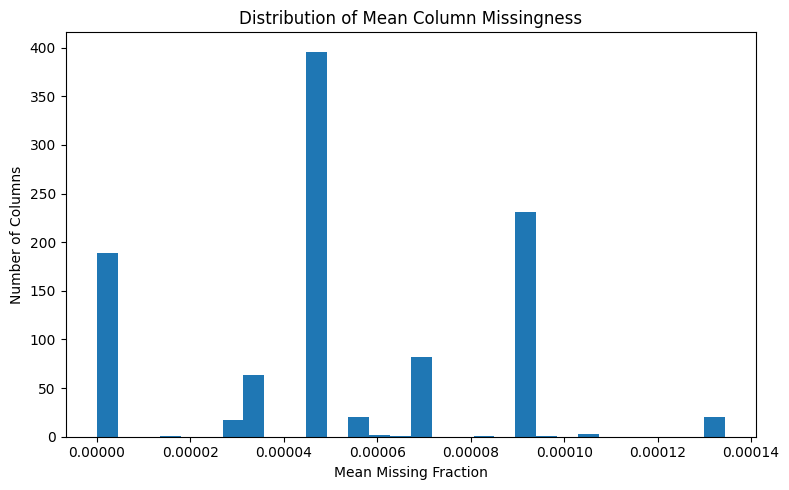

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(column_missingness_summary_df["mean_missing"], bins=30)
plt.title("Distribution of Mean Column Missingness")
plt.xlabel("Mean Missing Fraction")
plt.ylabel("Number of Columns")
plt.tight_layout()
plt.show()

## 12. Timestamp Coverage and Time-Gap Analysis Across All Turbines

In [27]:
timestamp_coverage_df = turbine_metadata_df[
    ["wind_farm", "turbine_id", "n_rows", "timestamp_min", "timestamp_max", "n_missing_timestamps"]
].copy()
timestamp_coverage_df.head(10)

,wind_farm,turbine_id,n_rows,timestamp_min,timestamp_max,n_missing_timestamps
0,Wind Farm A,0,54986,2022-08-04 06:10:00,2023-08-24 06:10:00,0
1,Wind Farm A,10,53592,2022-10-09 08:40:00,2023-10-18 08:40:00,0
2,Wind Farm A,13,54010,2022-04-30 13:20:00,2023-05-25 10:20:00,0
3,Wind Farm A,14,54197,2022-03-03 14:00:00,2023-03-16 18:40:00,0
4,Wind Farm A,17,55090,2022-10-31 15:20:00,2023-11-20 00:40:00,0
5,Wind Farm A,22,53036,2022-08-12 09:50:00,2023-08-20 09:50:00,0
6,Wind Farm A,24,55003,2022-04-24 15:00:00,2023-05-13 11:20:00,0
7,Wind Farm A,25,54712,2022-05-23 06:50:00,2023-06-09 02:30:00,0
8,Wind Farm A,26,53702,2022-10-12 10:20:00,2023-10-22 10:20:00,0
9,Wind Farm A,3,55487,2022-04-27 03:00:00,2023-05-20 01:10:00,0


In [28]:
time_gap_df.head(10)

,wind_farm,turbine_id,n_intervals,min_gap_minutes,median_gap_minutes,mean_gap_minutes,max_gap_minutes,p95_gap_minutes,n_gaps_gt_10min,n_gaps_gt_60min,n_gaps_gt_1440min
0,Wind Farm A,0,54985,10.0,10.0,10.082750,780.0,10.0,18,12,0
1,Wind Farm A,10,53591,10.0,10.0,10.049449,740.0,10.0,31,9,0
2,Wind Farm A,13,54009,10.0,10.0,10.394934,13730.0,10.0,34,16,2
3,Wind Farm A,14,54196,10.0,10.0,10.048712,780.0,10.0,15,8,0
4,Wind Farm A,17,55089,10.0,10.0,10.047741,740.0,10.0,29,9,0
5,Wind Farm A,22,53035,10.0,10.0,10.127652,1790.0,10.0,24,11,1
6,Wind Farm A,24,55002,10.0,10.0,10.049453,780.0,10.0,11,9,0
7,Wind Farm A,25,54711,10.0,10.0,10.049533,780.0,10.0,12,8,0
8,Wind Farm A,26,53701,10.0,10.0,10.055679,740.0,10.0,19,9,0
9,Wind Farm A,3,55486,10.0,10.0,10.067585,780.0,10.0,41,13,0


In [29]:
time_gap_summary_by_farm_df = (
    time_gap_df.groupby("wind_farm")
    .agg(
        median_of_median_gap_minutes=("median_gap_minutes", "median"),
        max_gap_minutes=("max_gap_minutes", "max"),
        min_gap_minutes=("min_gap_minutes", "min"),
    )
    .reset_index()
)
time_gap_summary_by_farm_df

,wind_farm,median_of_median_gap_minutes,max_gap_minutes,min_gap_minutes
0,Wind Farm A,10.0,13730.0,10.0
1,Wind Farm B,10.0,3110.0,10.0
2,Wind Farm C,10.0,14410.0,10.0


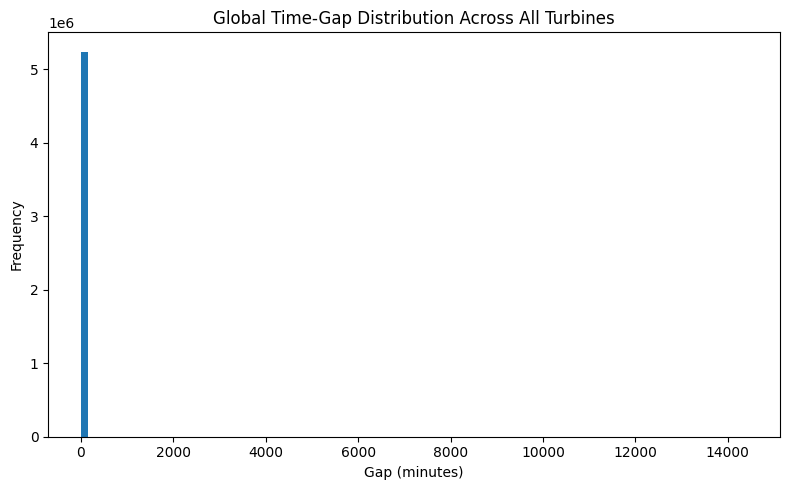

In [30]:
if not gap_distribution_df.empty:
    plt.figure(figsize=(8, 5))
    plt.hist(gap_distribution_df["gap_minutes"], bins=100)
    plt.title("Global Time-Gap Distribution Across All Turbines")
    plt.xlabel("Gap (minutes)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("No time-gap data available for global distribution plot.")

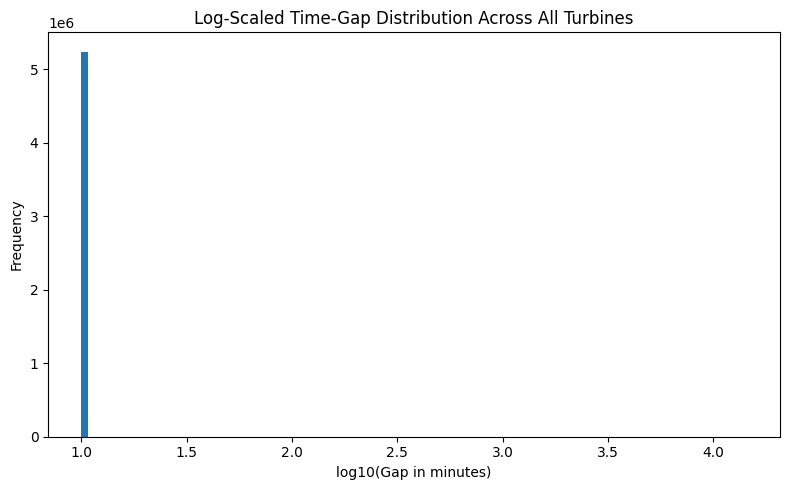

In [31]:
if not gap_distribution_df.empty:
    positive_gaps = gap_distribution_df.loc[gap_distribution_df["gap_minutes"] > 0, "gap_minutes"]
    plt.figure(figsize=(8, 5))
    plt.hist(np.log10(positive_gaps), bins=100)
    plt.title("Log-Scaled Time-Gap Distribution Across All Turbines")
    plt.xlabel("log10(Gap in minutes)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("No positive time-gap data available for log-scaled distribution plot.")

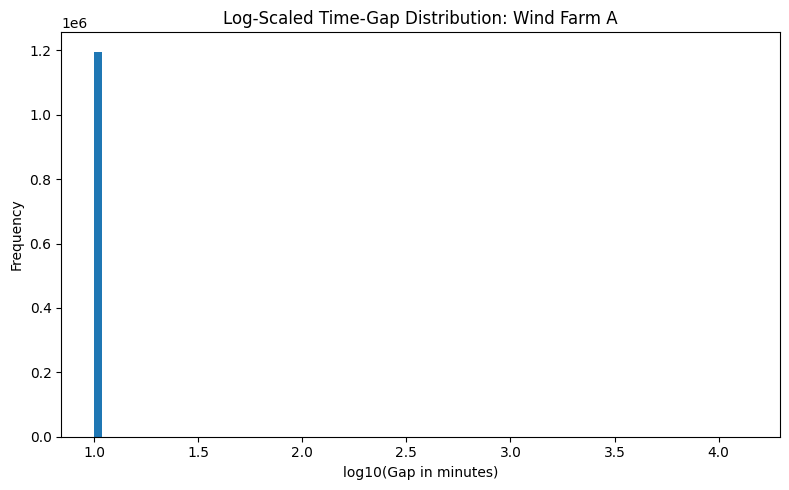

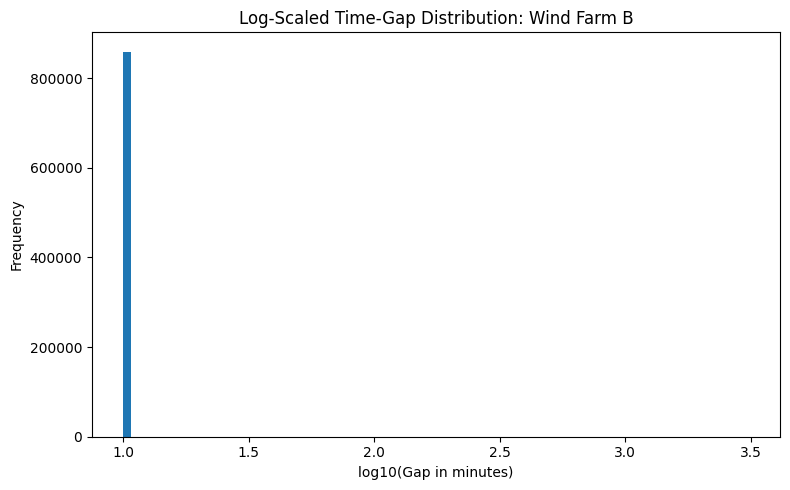

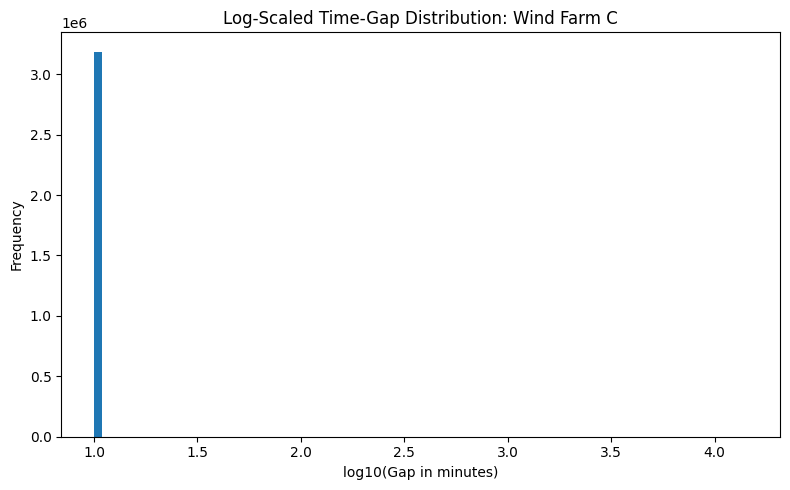

In [32]:
if not gap_distribution_df.empty:
    for wind_farm in sorted(gap_distribution_df["wind_farm"].unique()):
        farm_gaps = gap_distribution_df.loc[gap_distribution_df["wind_farm"] == wind_farm, "gap_minutes"]
        farm_gaps = farm_gaps[farm_gaps > 0]
        if len(farm_gaps) == 0:
            continue

        plt.figure(figsize=(8, 5))
        plt.hist(np.log10(farm_gaps), bins=80)
        plt.title(f"Log-Scaled Time-Gap Distribution: {wind_farm}")
        plt.xlabel("log10(Gap in minutes)")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
else:
    print("No time-gap data available for per-farm distribution plots.")

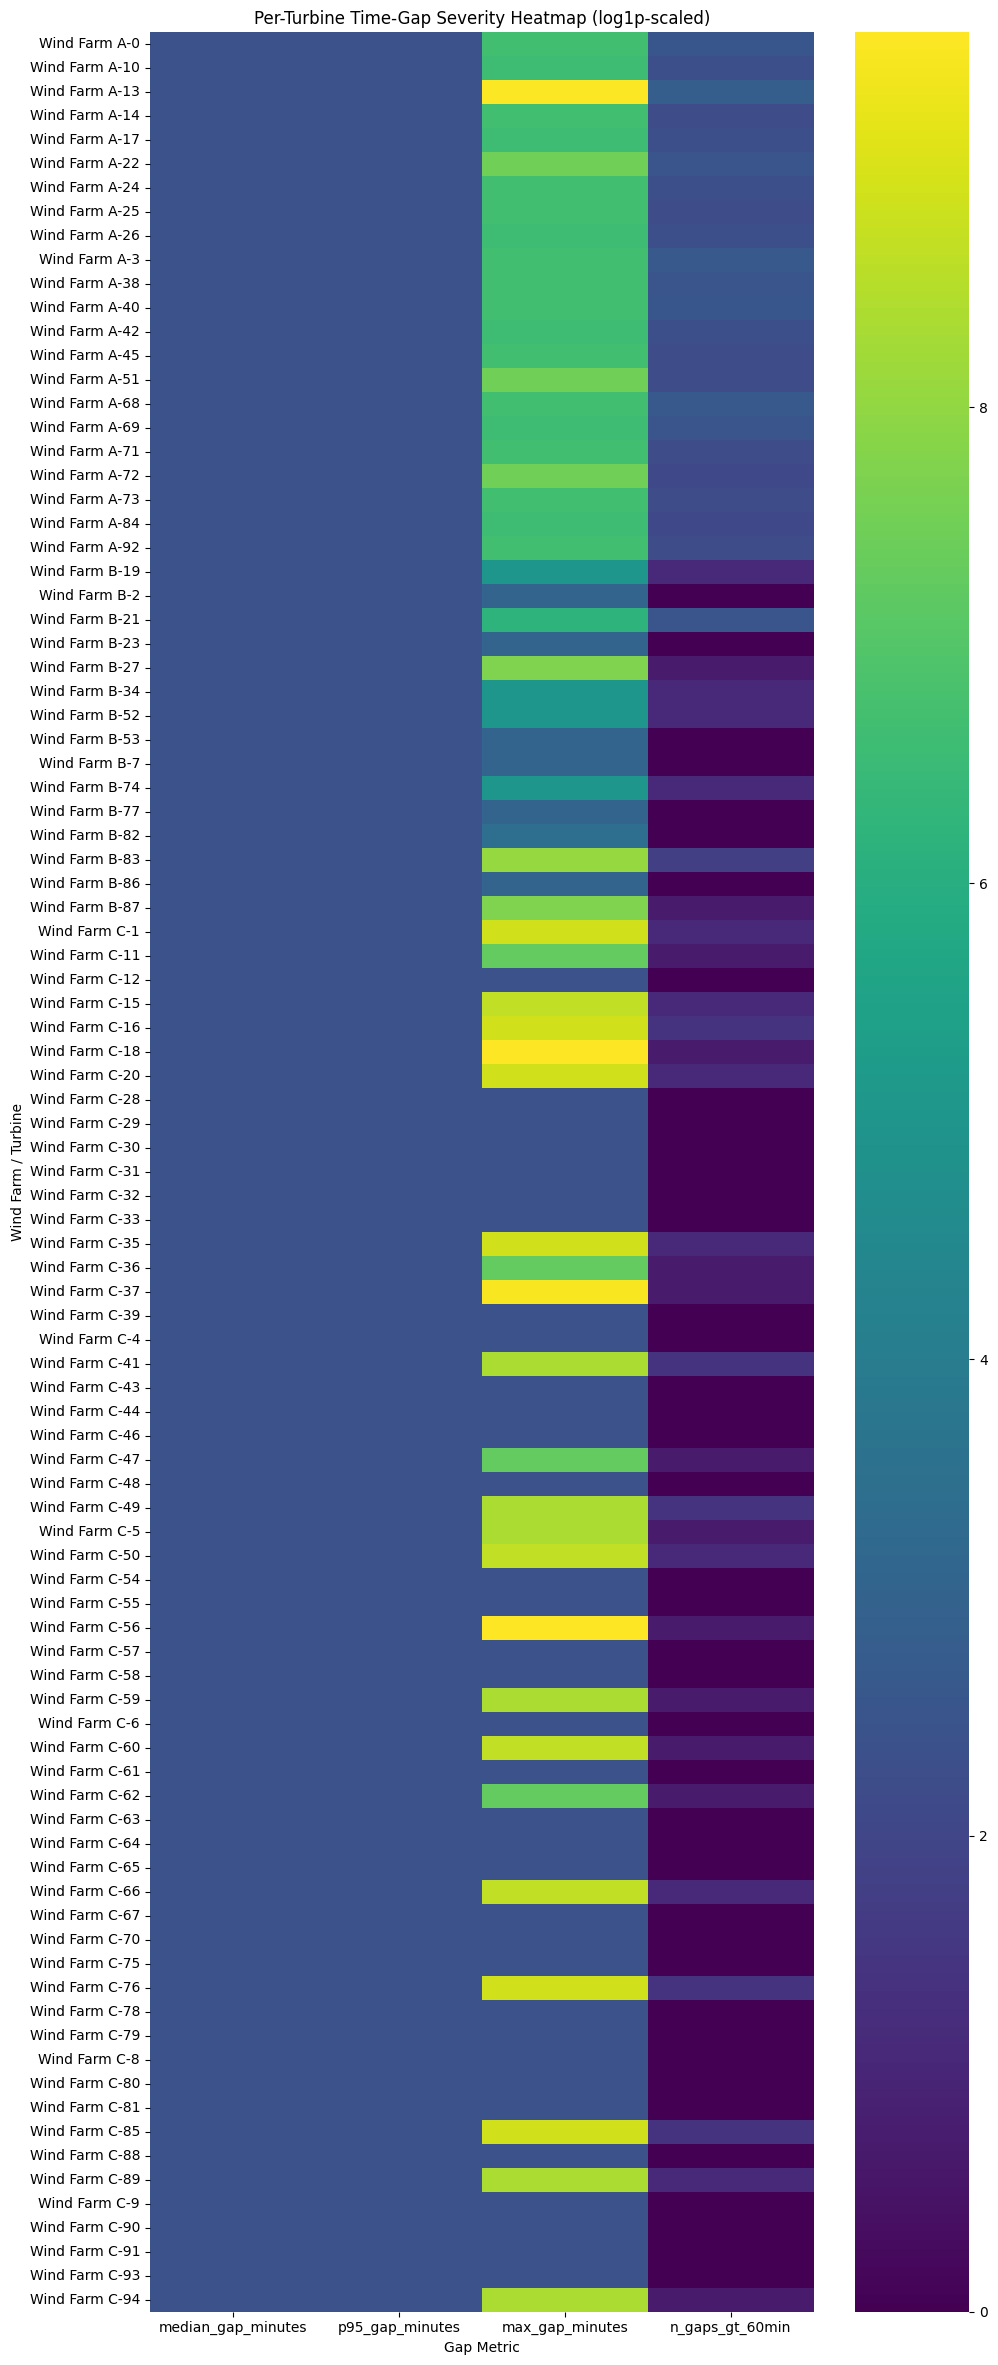

In [33]:
time_gap_heatmap_df = time_gap_df.set_index(["wind_farm", "turbine_id"])[
    ["median_gap_minutes", "p95_gap_minutes", "max_gap_minutes", "n_gaps_gt_60min"]
]

plt.figure(figsize=(10, max(6, len(time_gap_heatmap_df) * 0.25)))
sns.heatmap(np.log1p(time_gap_heatmap_df), cmap="viridis")
plt.title("Per-Turbine Time-Gap Severity Heatmap (log1p-scaled)")
plt.xlabel("Gap Metric")
plt.ylabel("Wind Farm / Turbine")
plt.tight_layout()
plt.show()

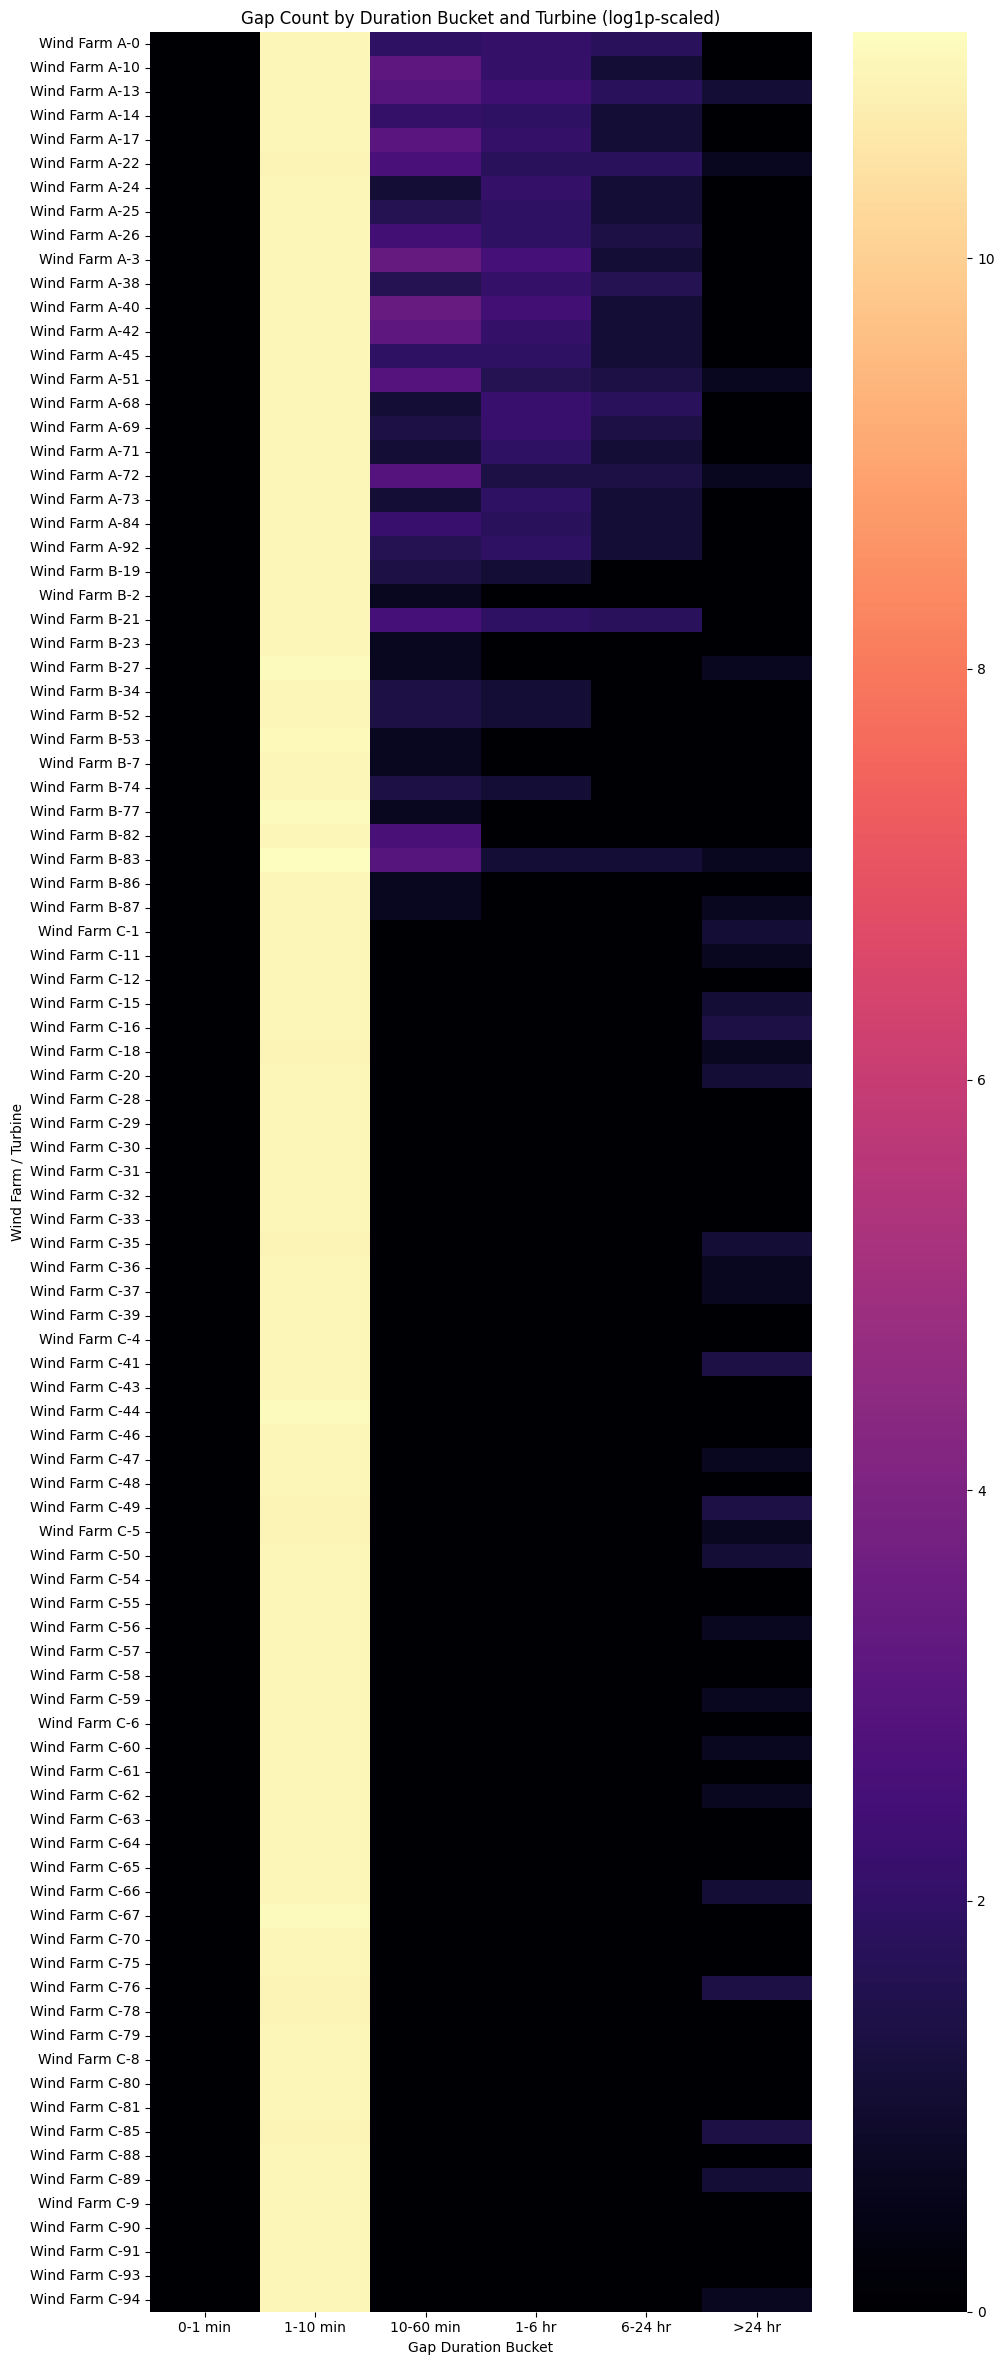

In [34]:
gap_labels = ["0-1 min", "1-10 min", "10-60 min", "1-6 hr", "6-24 hr", ">24 hr"]
gap_bucket_heatmap_df = (
    gap_bucket_summary_df.pivot_table(
        index=["wind_farm", "turbine_id"],
        columns="gap_bucket",
        values="count",
        fill_value=0,
    )
    .reindex(columns=gap_labels)
)

plt.figure(figsize=(10, max(6, len(gap_bucket_heatmap_df) * 0.25)))
sns.heatmap(np.log1p(gap_bucket_heatmap_df), cmap="magma")
plt.title("Gap Count by Duration Bucket and Turbine (log1p-scaled)")
plt.xlabel("Gap Duration Bucket")
plt.ylabel("Wind Farm / Turbine")
plt.tight_layout()
plt.show()

## Representative Turbine Sampling for Visual EDA

In [35]:
representative_turbines_df

,wind_farm,turbine_id,csv_path
0,Wind Farm A,0,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm A/datasets/0.csv
1,Wind Farm B,19,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm B/datasets/19.csv
2,Wind Farm C,1,/mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/raw/zenodo_windfarm_data/Wind Farm C/datasets/1.csv


In [36]:
representative_turbine_data: list[tuple[str, str, pd.DataFrame]] = []

for row in tqdm(representative_turbines_df.itertuples(index=False), total=len(representative_turbines_df)):
    wind_farm = row.wind_farm
    turbine_id = row.turbine_id
    csv_path = Path(row.csv_path)

    raw_df = load_scada_csv(csv_path)
    df = preprocess_scada_for_eda(raw_df)
    df = optimize_dtypes(df, skip_columns={"timestamp"})

    representative_turbine_data.append((wind_farm, turbine_id, df))

    del raw_df
    gc.collect()

print(f"Loaded {len(representative_turbine_data)} representative turbines.")

  0%|          | 0/3 [00:00<?, ?it/s]

Loaded 3 representative turbines.


## Sample Turbine Time-Based Missingness

In [37]:
sample_wind_farm, sample_turbine, sample_df = representative_turbine_data[0]
sample_df[["timestamp"]].head()

,timestamp
0,2022-08-04 06:10:00
1,2022-08-04 06:20:00
2,2022-08-04 06:30:00
3,2022-08-04 06:40:00
4,2022-08-04 06:50:00


In [38]:
sample_ts = sample_df["timestamp"].dropna().sort_values()
sample_gaps = sample_ts.diff().dropna().dt.total_seconds() / 60.0

print(f"Sample turbine: {sample_wind_farm} / {sample_turbine}")
print(f"Number of intervals: {len(sample_gaps)}")
sample_gaps.describe()

Sample turbine: Wind Farm A / 0
Number of intervals: 54985


count    54985.000000
mean        10.082750
std          6.774092
min         10.000000
25%         10.000000
50%         10.000000
75%         10.000000
max        780.000000
Name: timestamp, dtype: float64

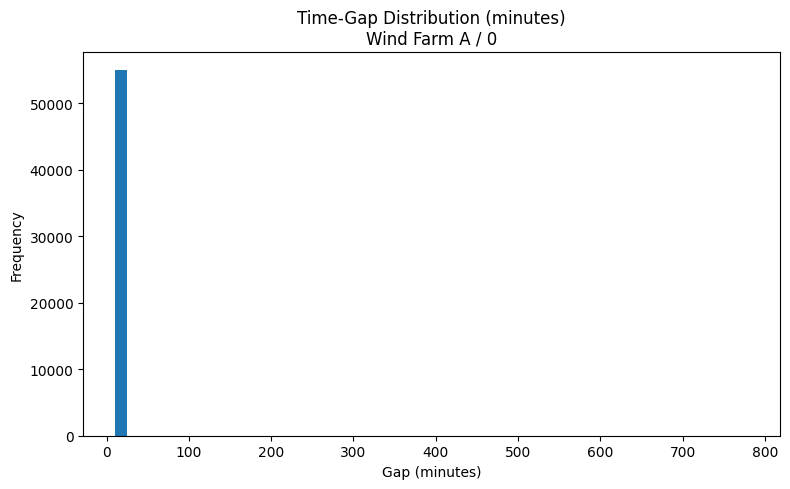

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(sample_gaps, bins=50)
plt.title(f"Time-Gap Distribution (minutes)\n{sample_wind_farm} / {sample_turbine}")
plt.xlabel("Gap (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

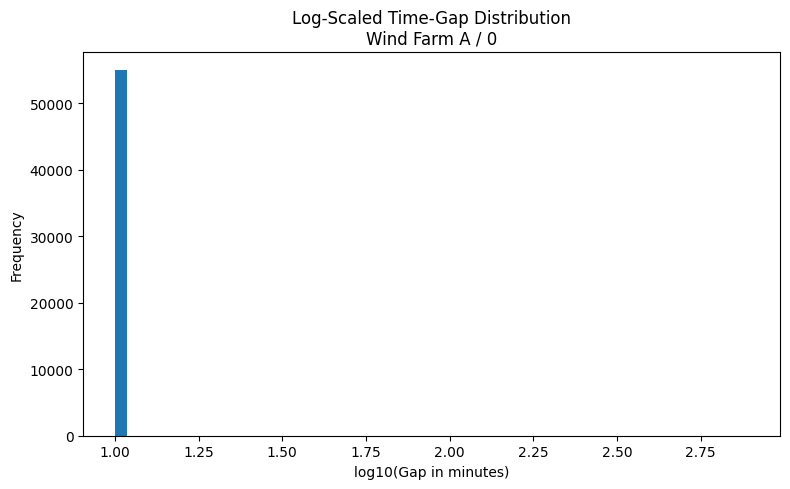

In [40]:
positive_sample_gaps = sample_gaps[sample_gaps > 0]

plt.figure(figsize=(8, 5))
plt.hist(np.log10(positive_sample_gaps), bins=50)
plt.title(f"Log-Scaled Time-Gap Distribution\n{sample_wind_farm} / {sample_turbine}")
plt.xlabel("log10(Gap in minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [41]:
large_sample_gaps = sample_gaps[sample_gaps > 60]
print(f"Number of large gaps (>60 minutes): {len(large_sample_gaps)}")
large_sample_gaps.describe()

Number of large gaps (>60 minutes): 12


count     12.000000
mean     380.000000
std      282.521117
min       70.000000
25%      165.000000
50%      260.000000
75%      730.000000
max      780.000000
Name: timestamp, dtype: float64

## Representative Signal Inspection

In [42]:
candidate_power_col = find_candidate_column(
    sample_df,
    patterns=["active_power", "power", "activepower", "p_avg", "kw"],
)

candidate_wind_col = find_candidate_column(
    sample_df,
    patterns=["wind_speed", "windspeed", "wind", "ws"],
)

print("Candidate power column:", candidate_power_col)
print("Candidate wind speed column:", candidate_wind_col)

Candidate power column: reactive_power_27_avg
Candidate wind speed column: wind_speed_3_avg


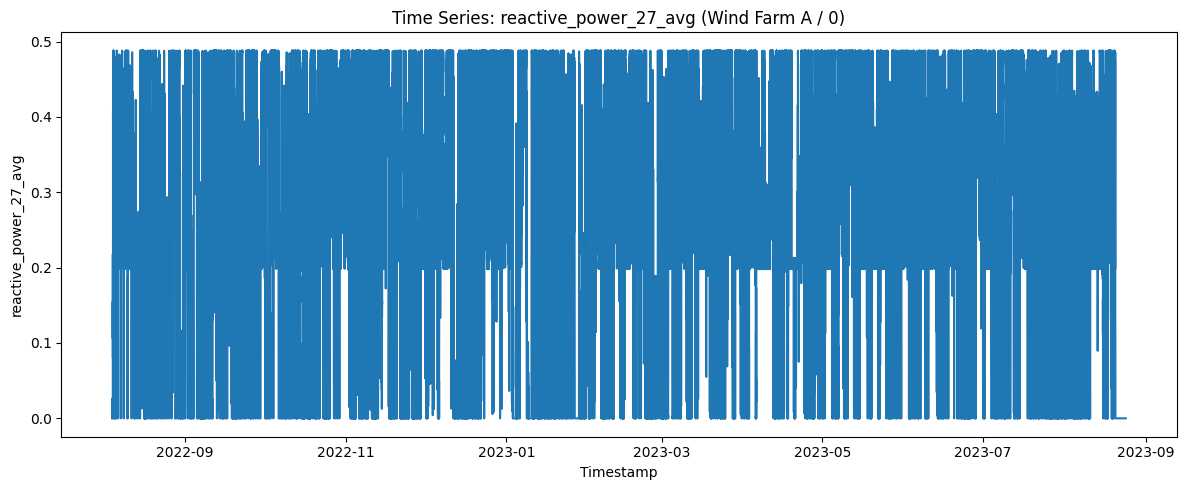

In [43]:
if candidate_power_col is not None:
    plt.figure(figsize=(12, 5))
    plt.plot(sample_df["timestamp"], sample_df[candidate_power_col])
    plt.title(f"Time Series: {candidate_power_col} ({sample_wind_farm} / {sample_turbine})")
    plt.xlabel("Timestamp")
    plt.ylabel(candidate_power_col)
    plt.tight_layout()
    plt.show()
else:
    print("No candidate power column found for the sample turbine.")

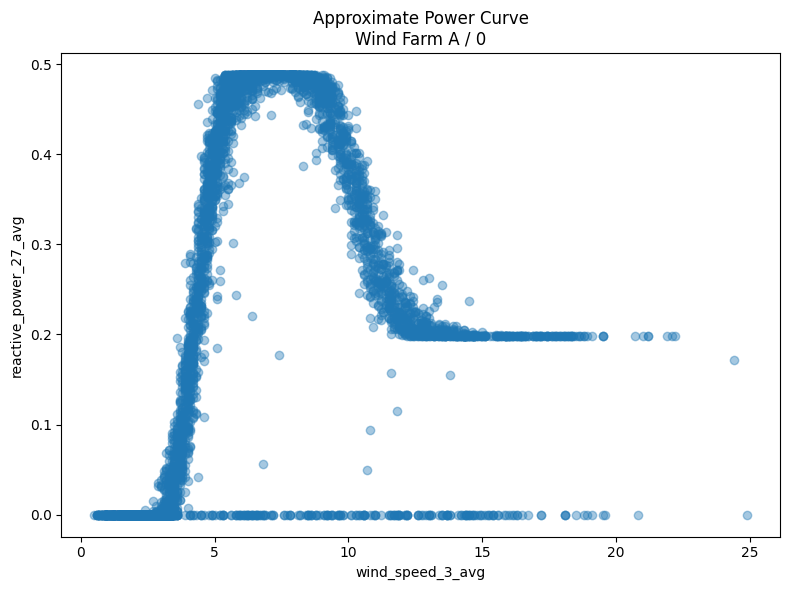

In [44]:
if candidate_power_col is not None and candidate_wind_col is not None:
    candidate_df = sample_df[[candidate_wind_col, candidate_power_col]].dropna()

    if not candidate_df.empty:
        plot_df = candidate_df.sample(
            n=min(5000, len(candidate_df)),
            random_state=RANDOM_SEED,
        )

        plt.figure(figsize=(8, 6))
        plt.scatter(plot_df[candidate_wind_col], plot_df[candidate_power_col], alpha=0.4)
        plt.title(f"Approximate Power Curve\n{sample_wind_farm} / {sample_turbine}")
        plt.xlabel(candidate_wind_col)
        plt.ylabel(candidate_power_col)
        plt.tight_layout()
        plt.show()
    else:
        print("Candidate columns exist, but no non-null paired observations were available.")
else:
    print("Could not create approximate power curve because candidate columns were not found.")

## Sample-Turbine Missingness Heatmap

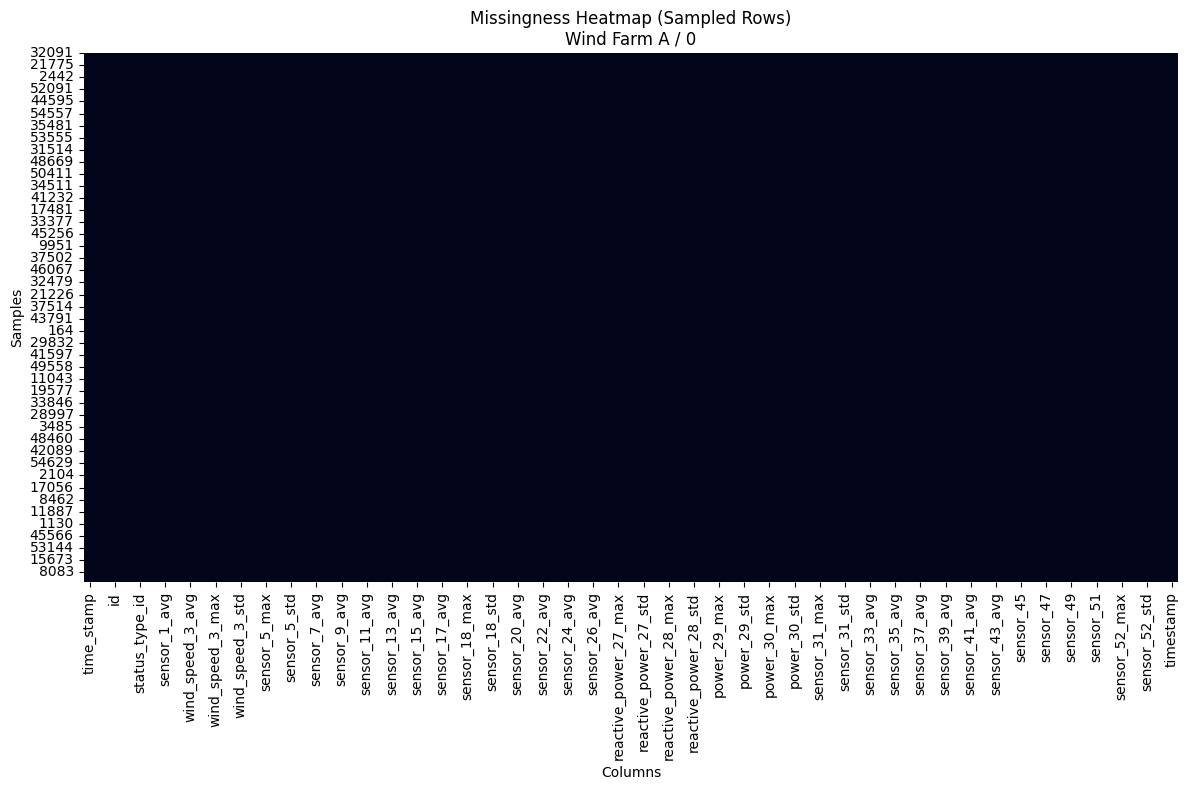

In [50]:
subset_df = sample_df.sample(
    n=min(5000, len(sample_df)),
    random_state=RANDOM_SEED,
)

missing_matrix = subset_df.isna()

plt.figure(figsize=(12, 8))
sns.heatmap(missing_matrix, cbar=False)
plt.title(f"Missingness Heatmap (Sampled Rows)\n{sample_wind_farm} / {sample_turbine}")
plt.xlabel("Columns")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

## Per-Farm Feature Metadata Review

In [46]:
for wind_farm, feature_df in feature_description_tables.items():
    print(f"\n=== {wind_farm} ===")
    display(feature_df.head(15))

    expected_cols = {"sensor_name", "description", "unit"}
    present_cols = {str(col) for col in feature_df.columns}

    print("Expected metadata columns present:")
    for col in sorted(expected_cols):
        print(f" - {col}: {col in present_cols}")


=== Wind Farm A ===


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
1,sensor_1,average,Wind absolute direction,�,True,False
2,sensor_2,average,Wind relative direction,�,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False
5,sensor_5,"maximum,minimum,std_dev,average",Pitch angle,�,True,False
6,sensor_6,average,Temperature in the hub controller,�C,False,False
7,sensor_7,average,Temperature in the top nacelle controller,�C,False,False
8,sensor_8,average,Temperature in the choke coils on the VCS-section,�C,False,False
9,sensor_9,average,Temperature on the VCP-board,�C,False,False


Expected metadata columns present:
 - description: True
 - sensor_name: True
 - unit: True

=== Wind Farm B ===


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,"maximum,minimum,average,std_dev",Total negative reactive power,kvarh,False,True
1,sensor_1,"maximum,std_dev,average,minimum",Total negative active power,kWh,False,True
2,sensor_2,"average,minimum,maximum,std_dev",Total positive reactive power,kvarh,False,True
3,sensor_3,"maximum,std_dev,minimum,average",Total positive active power,kWh,False,True
4,sensor_4,"average,maximum,minimum,std_dev",Absolute wind direction,�,True,False
5,sensor_5,"average,maximum,std_dev,minimum",Torque delta calculated,kNm,False,False
6,sensor_6,"average,minimum,std_dev,maximum",Wind speed anemometer 2 calculated,m/s,False,False
7,sensor_7,"std_dev,maximum,minimum,average",Cable load,%,False,False
8,sensor_8,"maximum,average,minimum,std_dev",Outside temperature,�C,False,False
9,sensor_9,"average,minimum,maximum,std_dev",Estimated tower natural frequency,mHz,False,False


Expected metadata columns present:
 - description: True
 - sensor_name: True
 - unit: True

=== Wind Farm C ===


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,"maximum,minimum,std_dev,average","ABB-LS Input K1, IL1",A,False,False
1,sensor_1,"maximum,minimum,std_dev,average",Generator acceleration,rpm/s,False,False
2,power_2,"average,maximum,std_dev,minimum",ABB-LS Active Power,kW,False,False
3,sensor_3,"average,maximum,minimum,std_dev",Active power aeration motor A,%,False,False
4,sensor_4,"average,maximum,minimum,std_dev",Active power aeration motor B,%,False,False
5,power_5,"average,maximum,minimum,std_dev",Active power grid side converter,kW,False,False
6,power_6,"average,maximum,minimum,std_dev",Active power HV grid,kW,False,False
7,sensor_7,"average,maximum,minimum,std_dev",Ambient temperature,Celsius,False,False
8,sensor_8,"average,maximum,minimum,std_dev",Generator angle speed,rad/s,False,False
9,sensor_9,"average,maximum,minimum,std_dev",Battery charge 1,A,False,False


Expected metadata columns present:
 - description: True
 - sensor_name: True
 - unit: True


## Preliminary EDA Findings

1. Raw SCADA and metadata CSV files require explicit semicolon-delimited parsing.
2. Feature names are not guaranteed to represent the same physical variables across wind farms.
3. Schema overlap is descriptive only and should not be used to force a common modeling schema.
4. Feature harmonization must later be based on `feature_description.csv`, especially sensor descriptions and units.
5. Event metadata is available and should be used next to define the target variable and prediction formulation.
6. Missingness varies across turbines and columns, indicating heterogeneous sensor reliability.
7. Time-gap analysis shows irregular sampling intervals and occasional large outages, which motivates time-aware cleaning.
8. Visual inspection of representative turbines provides concrete examples of the structural patterns observed globally.

## Save EDA Summary Outputs

In [47]:
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dataset_inventory_df.to_csv(EDA_OUTPUT_DIR / "dataset_inventory_summary.csv", index=False)
feature_description_summary_df.to_csv(EDA_OUTPUT_DIR / "feature_description_summary.csv", index=False)
event_info_summary_df.to_csv(EDA_OUTPUT_DIR / "event_info_summary.csv", index=False)

turbine_metadata_df.to_csv(EDA_OUTPUT_DIR / "turbine_metadata_eda_summary.csv", index=False)
dataframe_summary_df.to_csv(EDA_OUTPUT_DIR / "dataframe_summary.csv", index=False)

schema_presence_df.to_csv(EDA_OUTPUT_DIR / "schema_presence_by_turbine.csv", index=False)
column_presence_summary_df.to_csv(EDA_OUTPUT_DIR / "column_presence_summary.csv", index=False)

missingness_df.to_csv(EDA_OUTPUT_DIR / "missingness_summary.csv", index=False)
column_missingness_df.to_csv(EDA_OUTPUT_DIR / "column_missingness_by_turbine.csv", index=False)
column_missingness_summary_df.to_csv(EDA_OUTPUT_DIR / "column_missingness_summary.csv", index=False)
column_missingness_by_farm_df.to_csv(EDA_OUTPUT_DIR / "column_missingness_by_farm.csv", index=False)

timestamp_coverage_df.to_csv(EDA_OUTPUT_DIR / "timestamp_coverage_summary.csv", index=False)
time_gap_df.to_csv(EDA_OUTPUT_DIR / "time_gap_summary.csv", index=False)
gap_bucket_summary_df.to_csv(EDA_OUTPUT_DIR / "gap_bucket_summary.csv", index=False)

representative_turbines_df.to_csv(EDA_OUTPUT_DIR / "representative_turbines.csv", index=False)

print(f"EDA summaries saved to: {EDA_OUTPUT_DIR}")

EDA summaries saved to: /mnt/c/grad_school/northeastern/courses/ie7275/project/wind-turbine-fault-detection/data/interim/eda


## Sandbox